In [ ]:
import os
os.chdir(r'c:\Users\QQ\OneDrive\桌面\课程设计报告_Lendingclub\ipynb文件（代码和输出结果）')

In [22]:
import pandas as pd
df = pd.read_csv("loan_onehot.csv")
df

,loan_amnt,term,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,dti,...,addr_state_SD,addr_state_TN,addr_state_TX,addr_state_UT,addr_state_VA,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY
0,5000,36,2,10,3,24000,2,48,1,27,...,0,0,0,0,0,0,0,0,0,0
1,2500,60,3,0,3,30000,1,48,10,1,...,0,0,0,0,0,0,0,0,0,0
2,2400,36,3,10,3,12252,3,48,1,8,...,0,0,0,0,0,0,0,0,0,0
3,10000,36,3,10,3,49200,1,48,1,20,...,0,0,0,0,0,0,0,0,0,0
4,3000,60,2,1,3,80000,1,48,2,17,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887293,10000,36,2,8,3,31000,2,11,2,28,...,0,0,0,0,0,0,0,0,0,0
887294,24000,36,2,10,2,79000,2,11,2,3,...,0,0,0,0,0,0,0,0,0,0
887295,13000,60,4,5,3,35000,2,11,2,30,...,0,1,0,0,0,0,0,0,0,0
887296,12000,60,5,1,3,64400,1,11,2,27,...,0,0,0,0,0,0,0,0,0,0


In [23]:
# 导入必要的库
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# 目标列名为'grade'
# 首先分割出10%的数据作为测试集
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('grade', axis=1),
    df['grade'],
    test_size=0.1,  # 10% 作为测试集
    random_state=123
)

# 然后从剩余的90%中分割出20%作为验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,  # 从剩余的90%中再分割出20%作为验证集
    random_state=123
)

# 创建随机森林分类器实例，并设置指定的参数
rf_classifier2 = RandomForestClassifier(
    n_estimators=132, 
    criterion='entropy', 
    max_depth=39, 
    max_features='sqrt', 
    min_samples_leaf=2, 
    min_samples_split=6, 
    random_state=111,  # 确保结果的可复现性
    class_weight='balanced'
)

# 训练模型
rf_classifier2.fit(X_train, y_train)

# 使用验证集进行预测
y_val_pred = rf_classifier2.predict(X_val)
# 计算验证集的准确率
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"验证集准确率: {val_accuracy:.2f}")

验证集准确率: 0.68


In [24]:
# 使用测试集对模型进行评价
y_test_pred = rf_classifier2.predict(X_test)
# 计算测试集的准确率
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"测试集准确率: {test_accuracy:.2f}")

测试集准确率: 0.68


In [25]:
# 假设df是你的DataFrame
df2 = df.loc[:, ~df.columns.str.contains('addr_state')]

In [26]:
df2

,loan_amnt,term,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,dti,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,5000,36,2,10,3,24000,2,48,1,27,...,0,0,0,0,0,0,0,0,0,0
1,2500,60,3,0,3,30000,1,48,10,1,...,0,0,0,0,0,0,0,0,0,0
2,2400,36,3,10,3,12252,3,48,1,8,...,0,0,0,0,0,0,0,1,0,0
3,10000,36,3,10,3,49200,1,48,1,20,...,0,0,0,0,0,1,0,0,0,0
4,3000,60,2,1,3,80000,1,48,2,17,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887293,10000,36,2,8,3,31000,2,11,2,28,...,0,0,0,0,0,0,0,0,0,0
887294,24000,36,2,10,2,79000,2,11,2,3,...,1,0,0,0,0,0,0,0,0,0
887295,13000,60,4,5,3,35000,2,11,2,30,...,0,0,0,0,0,0,0,0,0,0
887296,12000,60,5,1,3,64400,1,11,2,27,...,0,0,0,0,0,0,0,0,0,0


In [27]:
# 导入必要的库
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# 目标列名为'grade'
# 首先分割出10%的数据作为测试集
X_train, X_test, y_train, y_test = train_test_split(
    df2.drop('grade', axis=1),
    df2['grade'],
    test_size=0.1,  # 10% 作为测试集
    random_state=123
)

# 然后从剩余的90%中分割出20%作为验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,  # 从剩余的90%中再分割出20%作为验证集
    random_state=123
)

# 创建随机森林分类器实例，并设置指定的参数
rf_classifier = RandomForestClassifier(
    n_estimators=132, 
    criterion='entropy', 
    max_depth=39, 
    max_features='sqrt', 
    min_samples_leaf=2, 
    min_samples_split=6, 
    random_state=111,  # 确保结果的可复现性
    class_weight='balanced'
)

# 训练模型
rf_classifier.fit(X_train, y_train)

# 使用验证集进行预测
y_val_pred = rf_classifier.predict(X_val)
# 计算验证集的准确率
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"验证集准确率: {val_accuracy:.2f}")

验证集准确率: 0.72


In [28]:
# 使用测试集对模型进行评价
y_test_pred = rf_classifier.predict(X_test)
# 计算测试集的准确率
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"测试集准确率: {test_accuracy:.2f}")

测试集准确率: 0.72


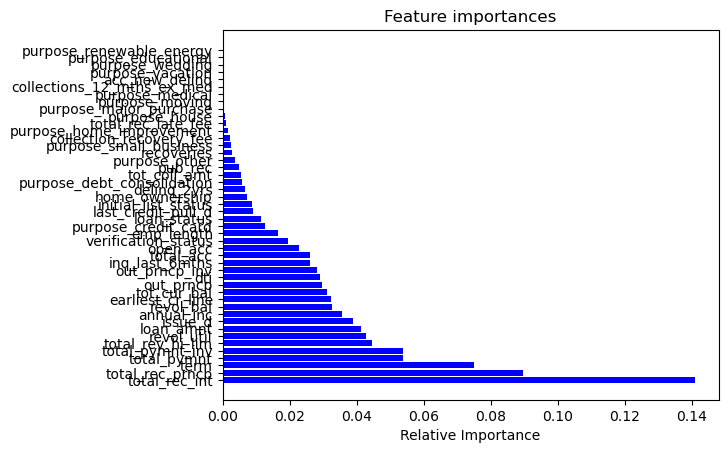

In [29]:
# 获取特征重要性并绘图
feature_importances = rf_classifier.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure()
plt.title("Feature importances")
plt.barh(range(len(indices)), feature_importances[indices], color='b', align='center')
# 使用 X_train 的列名作为 y 轴的标签
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()